# Exploratory Data Analysis (EDA) for Liquefaction Assessment

> Understanding and preprocessing geotechnical data for machine learning

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00-eda-liquefaction-exercise.ipynb)

**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00-eda-liquefaction.ipynb)

## Introduction

Exploratory Data Analysis (EDA) is a critical first step in any machine learning project. For geotechnical engineering applications, EDA helps us:

- Understand the physical characteristics of our data
- Identify data quality issues (missing values, outliers, errors)
- Discover relationships between geotechnical parameters
- Make informed decisions about preprocessing and feature engineering
- Validate that data aligns with our engineering understanding

### Liquefaction and Lateral Spreading

Soil liquefaction occurs in saturated loose sandy soils subjected to rapid loading conditions, such as earthquakes. The generation of excess pore water pressure can lead to a sudden reduction in soil strength and stiffness. In gently sloping ground, this may generate lateral displacements known as **lateral spreading**.

### Dataset

We'll analyze the lateral spreading dataset from:

> Durante, M. G., & Rathje, E. M. (2021). An exploration of the use of machine learning to predict lateral spreading. *Earthquake Spectra*, 37(4), 2288-2314.

**Classification criteria**: Sites with >0.3 m lateral displacement are classified as experiencing lateral spreading (Target=1).

**Key features**:
- **GWD (m)**: Ground Water Depth - distance from surface to water table
- **L (km)**: Distance to nearest free face (river, channel)
- **Slope (%)**: Ground slope angle
- **PGA (g)**: Peak Ground Acceleration from earthquake
- **Elevation**: Site elevation (will be removed as Durante & Rathje found it less significant)
- **Target**: Binary classification (0 = no lateral spreading, 1 = lateral spreading)

### Install packages

In [6]:
!pip3 install pandas numpy matplotlib seaborn scipy scikit-learn --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Users/krishna/courses/CE397-Scientific-MachineLearning/utp-sciml/env/bin/python -m pip install --upgrade pip


## 1. Import Libraries and Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [8]:
# Load the liquefaction dataset
df = pd.read_csv('https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/00-mlp-dtree/RF_YN_Model3.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} samples, {df.shape[1]} features")

Dataset loaded successfully!
Shape: 7291 samples, 7 features


## 2. Initial Data Exploration

In [9]:
# First look at the data
df.head(10)

,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g),Target
0,182,0.370809,0.909116,0.319117,5.465739,0.546270,0
1,15635,1.300896,1.123009,0.211770,0.905948,0.532398,0
2,8292,1.300896,0.847858,0.195947,0.849104,0.532398,0
3,15629,1.788212,2.044325,0.115795,0.451034,0.542307,0
4,183,1.637517,2.003797,0.137265,0.941866,0.545784,1
5,158,1.165643,0.992154,0.073885,2.699290,0.535794,0
6,180,2.121364,1.933611,0.119745,1.187781,0.528980,0
7,173,1.288666,1.191561,0.040633,2.766043,0.539045,1
8,161,1.884515,1.692008,0.064009,0.173425,0.535902,1
9,179,1.482130,1.488147,0.003209,3.220948,0.539283,1


In [10]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7291 entries, 0 to 7290
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Test ID    7291 non-null   int64  
 1   GWD (m)    7291 non-null   float64
 2   Elevation  7291 non-null   float64
 3   L (km)     7291 non-null   float64
 4   Slope (%)  7291 non-null   float64
 5   PGA (g)    7291 non-null   float64
 6   Target     7291 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 398.9 KB


In [11]:
# Statistical summary
df.describe()

,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g),Target
count,7291.000000,7291.000000,7.291000e+03,7291.000000,7291.000000,7291.000000,7291.000000
mean,23244.407900,2.075960,-9.427646e+20,1.018893,1.139434,0.439751,0.419010
std,15980.410687,0.641597,5.585343e+21,0.646159,1.133215,0.042140,0.493431
min,2.000000,0.370809,-3.402820e+22,0.000000,0.000000,0.328797,0.000000
25%,7826.500000,1.636752,2.375436e+00,0.487862,0.452506,0.407541,0.000000
50%,23848.000000,1.983148,3.585004e+00,0.948660,0.806480,0.439723,0.000000
75%,37277.500000,2.460715,4.503760e+00,1.478798,1.401399,0.470760,1.000000
max,57855.000000,6.047182,7.892973e+00,3.289537,10.922902,0.567631,1.000000


### Geotechnical Interpretation of Summary Statistics

Let's interpret these statistics from a geotechnical perspective:

- **GWD (Ground Water Depth)**: 
  - Range: Check if values are physically plausible (typically 0-5m for liquefaction-prone sites)
  - Mean vs. Median: Indicates distribution symmetry
  
- **PGA (Peak Ground Acceleration)**:
  - Typical range: 0.1g - 1.0g for significant earthquakes
  - Higher PGA → More severe shaking → Higher liquefaction risk
  
- **Slope**:
  - Range: Should be non-negative, typically 0-30%
  - Steeper slopes → More lateral spreading potential
  
- **Distance (L)**:
  - Sites closer to free faces show more lateral movement

Target Variable Distribution:
Target
0    4236
1    3055
Name: count, dtype: int64

Class Proportions:
Target
0    0.58099
1    0.41901
Name: proportion, dtype: float64


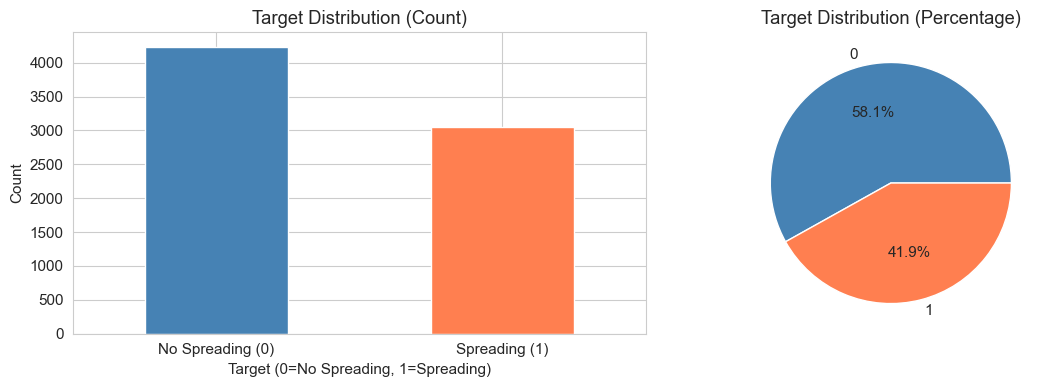

In [12]:
# Target variable distribution - checking class balance
print("Target Variable Distribution:")
print(df['Target'].value_counts())
print("\nClass Proportions:")
print(df['Target'].value_counts(normalize=True))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xlabel('Target (0=No Spreading, 1=Spreading)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Spreading (0)', 'Spreading (1)'], rotation=0)

df['Target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Target Distribution (Percentage)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Note on Class Imbalance**: If one class significantly outnumbers the other, we may need to consider:
- Stratified sampling during train-test split
- Class weighting in models
- Appropriate evaluation metrics (precision, recall, F1-score, AUC-ROC)

## 3. Missing Data Analysis

In [13]:
# Check for missing values
missing_data = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_table = missing_table[missing_table['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

if len(missing_table) > 0:
    print("Missing Data Summary:")
    print(missing_table)
else:
    print("✓ No missing values detected in the dataset!")

✓ No missing values detected in the dataset!


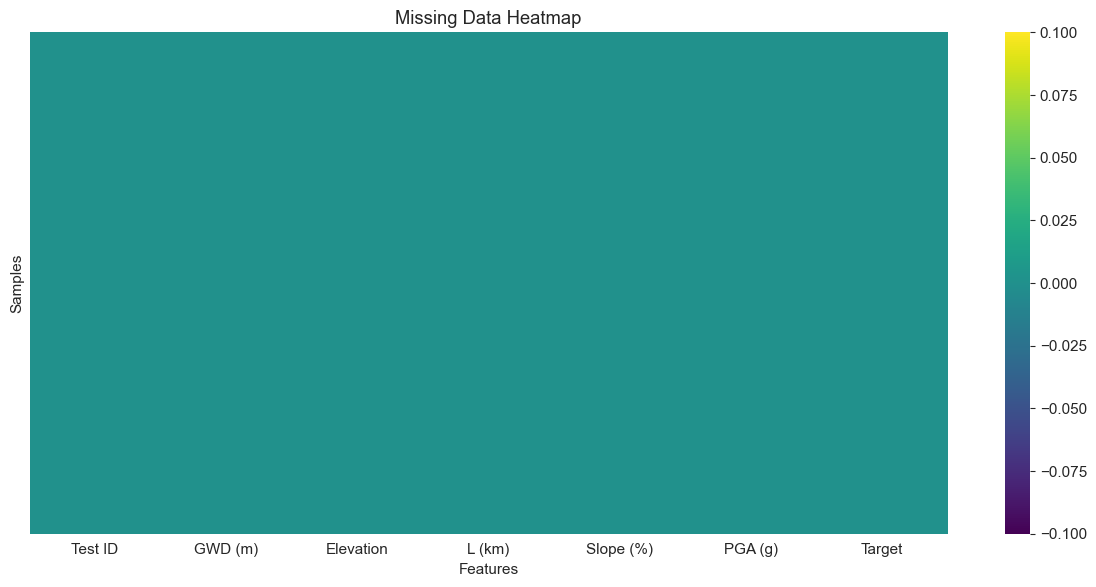

In [14]:
# Visualize missing data pattern
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

### Handling Missing Data - Geotechnical Considerations

**Types of Missingness**:
1. **MCAR (Missing Completely At Random)**: No pattern to missing data
2. **MAR (Missing At Random)**: Missingness related to observed variables
3. **MNAR (Missing Not At Random)**: Missingness related to the missing value itself

**Strategies for Geotechnical Data**:
- **Deletion**: Remove samples if <5% missing and MCAR
- **Imputation**: 
  - Mean/Median: For continuous variables (GWD, PGA)
  - Mode: For categorical variables (soil type)
  - Domain knowledge: Use typical values from similar geological conditions
  - Advanced: KNN or iterative imputation
- **Keep as feature**: Sometimes missingness itself is informative (e.g., no GWD measurement might indicate deep water table)

## 4. Univariate Analysis - Distribution of Individual Features

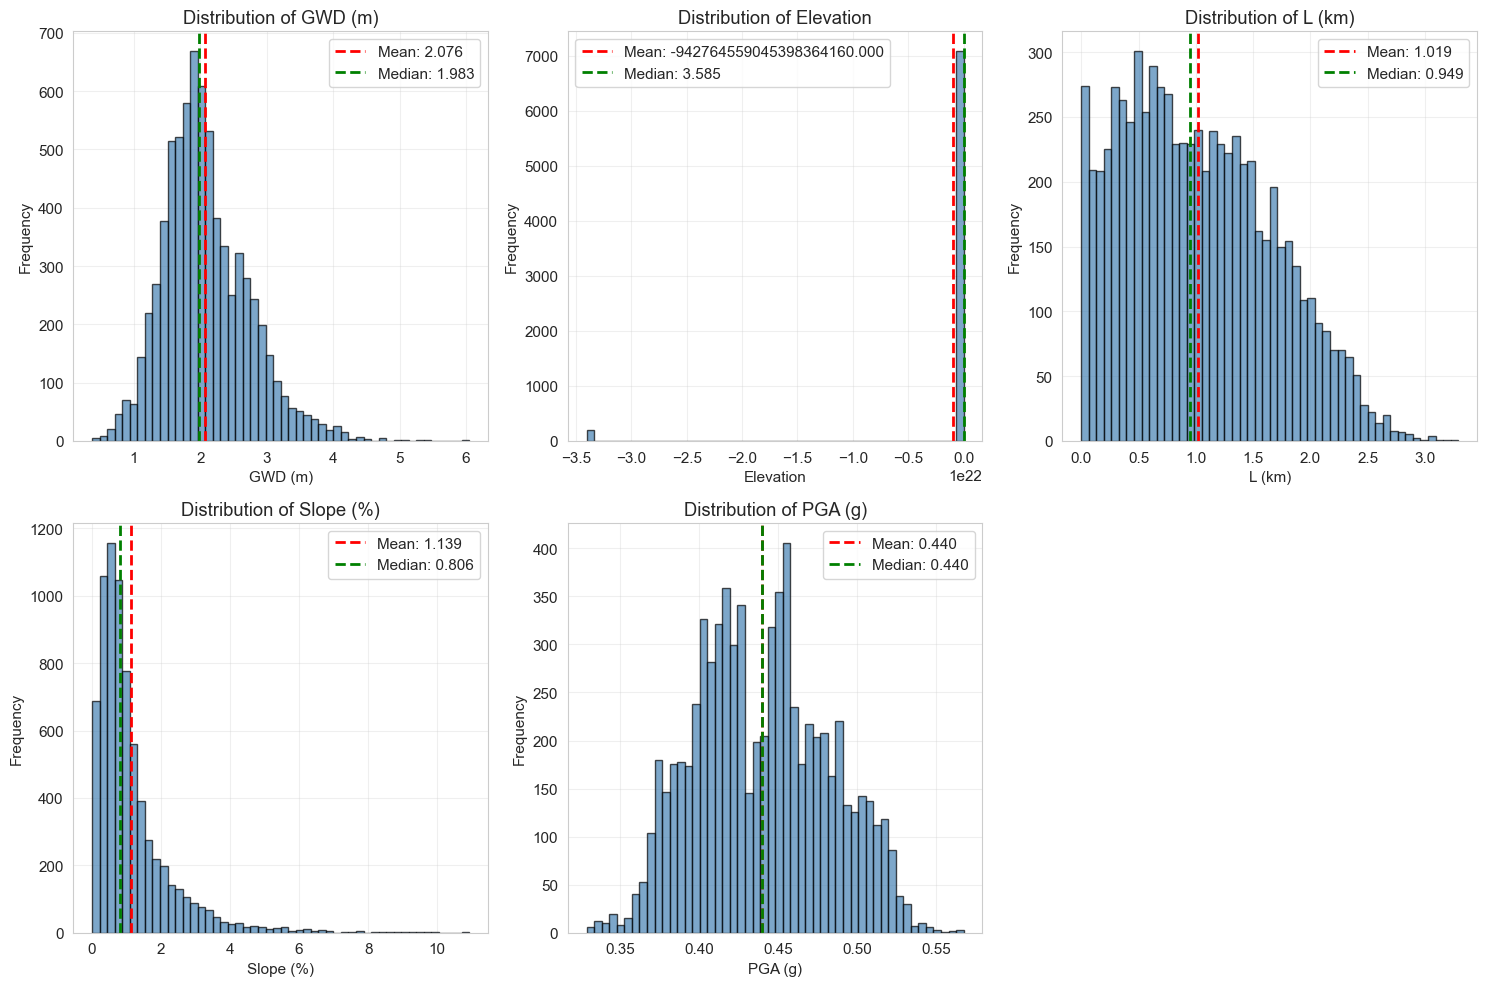

In [15]:
# Select numerical features (excluding Test ID and Target)
numerical_features = ['GWD (m)', 'Elevation', 'L (km)', 'Slope (%)', 'PGA (g)']

# Create histograms with KDE for all numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df[feature], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[feature].mean():.3f}')
    axes[idx].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[feature].median():.3f}')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Hide the last subplot if not needed
if len(numerical_features) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

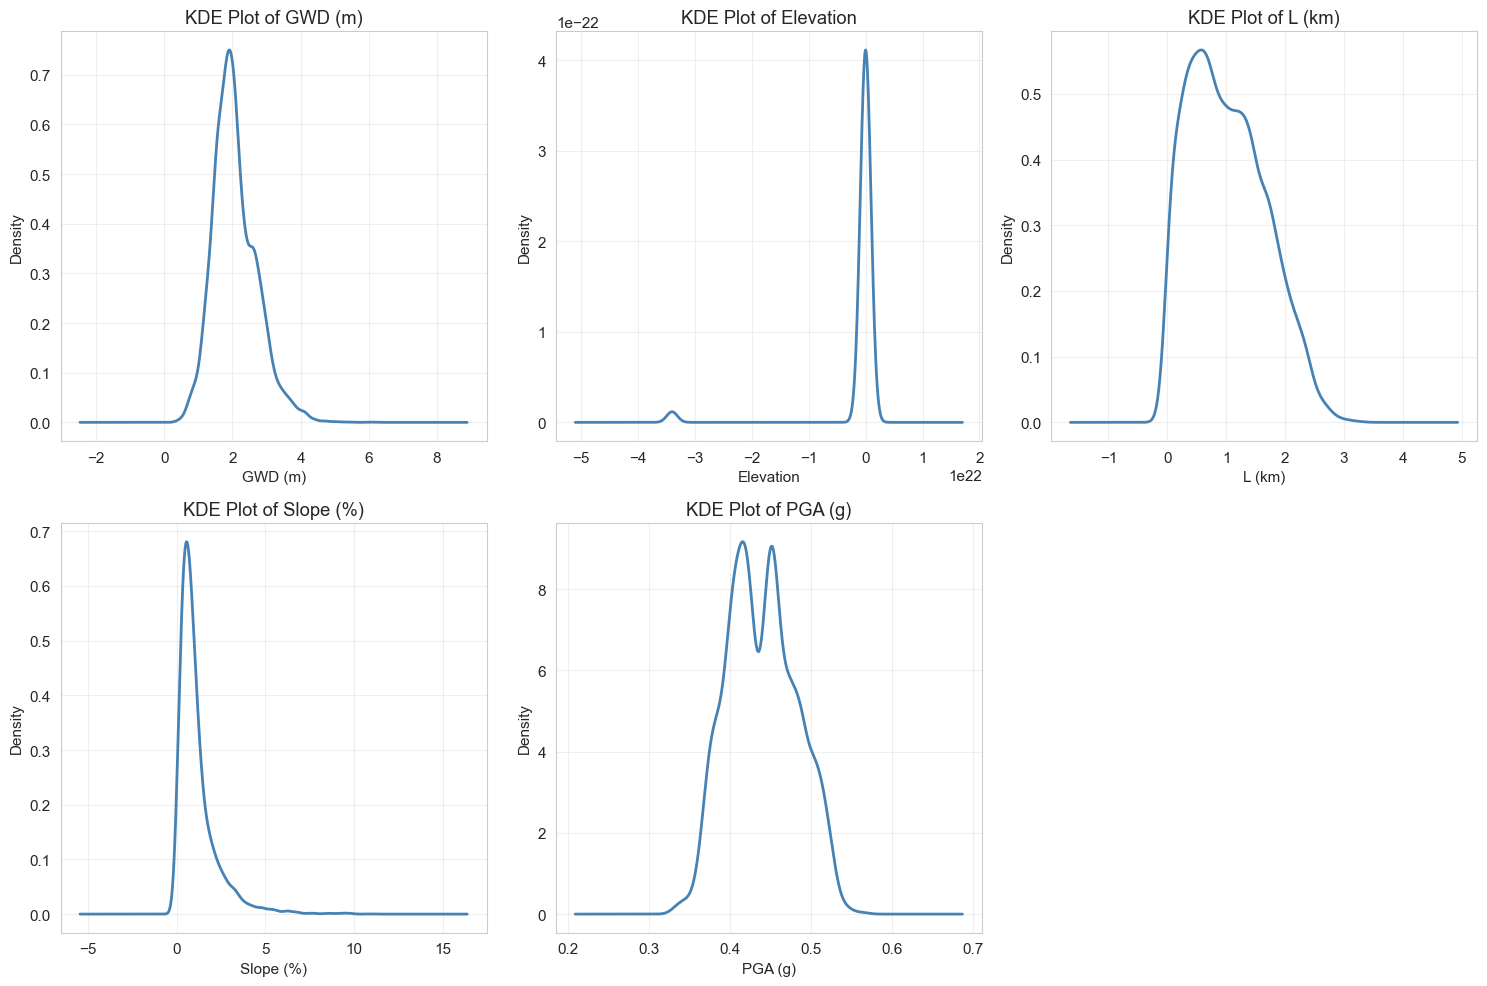

In [16]:
# KDE plots for smoother distribution visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    df[feature].plot(kind='kde', ax=axes[idx], color='steelblue', linewidth=2)
    axes[idx].set_title(f'KDE Plot of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True, alpha=0.3)

if len(numerical_features) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

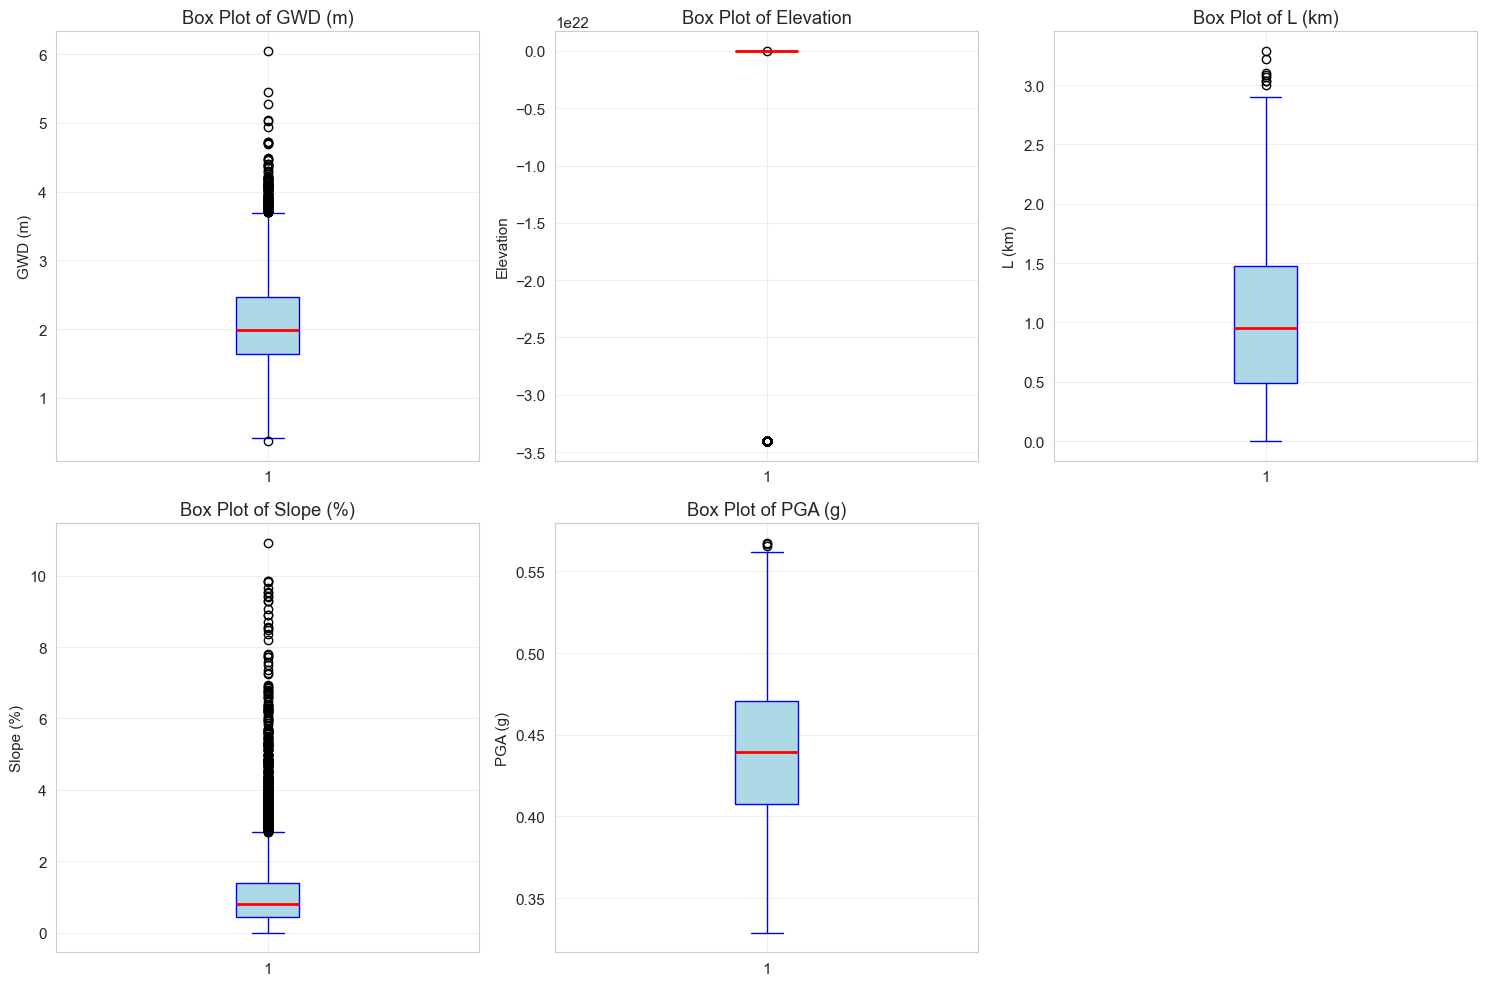

In [17]:
# Box plots to visualize spread and outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    axes[idx].boxplot(df[feature].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='blue'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='blue'),
                     capprops=dict(color='blue'))
    axes[idx].set_title(f'Box Plot of {feature}')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

if len(numerical_features) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Alternative: Combined Histogram + Box Plot Visualization

A more compact and publication-ready visualization that combines distribution and outlier information in a single plot for each feature.

In [ ]:
# Combined histogram and box plot for each feature
import matplotlib.gridspec as gridspec

# Select key features (excluding Elevation for cleaner visualization)
key_features = ["GWD (m)", "L (km)", "Slope (%)", "PGA (g)"]

for feature in key_features:
    # Create a grid of subplots using gridspec
    fig = plt.figure(figsize=(8, 5))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4])
    
    # Plot the box plot in the top subplot
    ax1 = plt.subplot(gs[0])
    sns.boxplot(data=df[feature], ax=ax1, 
                flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5}, 
                orient="h", color="lightblue")
    ax1.set_xlabel(None)
    ax1.set_ylabel(None)
    ax1.set_yticks([])  # Remove y-ticks
    # Remove the boundary around the subplot
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    
    # Plot the histogram in the bottom subplot
    ax2 = plt.subplot(gs[1], sharex=ax1)
    sns.histplot(data=df[feature], ax=ax2, color="skyblue", bins=30, edgecolor="black", alpha=0.7)
    ax2.set_xlabel(feature, fontsize=13, fontweight="bold")
    ax2.set_ylabel("Count", fontsize=12)
    
    # Add mean and median lines
    ax2.axvline(df[feature].mean(), color="red", linestyle="--", linewidth=2, 
                label=f"Mean: {df[feature].mean():.3f}")
    ax2.axvline(df[feature].median(), color="green", linestyle="--", linewidth=2, 
                label=f"Median: {df[feature].median():.3f}")
    ax2.legend(fontsize=10)
    
    # Show xticks on both top and bottom
    ax1.tick_params(axis="x", bottom=True, direction="inout")
    ax2.tick_params(axis="x", bottom=True, top=True, direction="inout", length=8, labelsize=11)
    ax2.tick_params(axis="y", labelsize=11)
    ax2.grid(True, alpha=0.3, axis="y")
    
    # Remove vertical gap between subplots
    plt.subplots_adjust(hspace=0.0)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [18]:
# Calculate skewness and kurtosis
print("Skewness and Kurtosis Analysis:\n")
print("{:<15} {:<12} {:<12} {:<20}".format('Feature', 'Skewness', 'Kurtosis', 'Interpretation'))
print("-" * 65)

for feature in numerical_features:
    skew = df[feature].skew()
    kurt = df[feature].kurtosis()
    
    # Interpretation
    if abs(skew) < 0.5:
        skew_interp = "Fairly symmetric"
    elif skew > 0:
        skew_interp = "Right-skewed"
    else:
        skew_interp = "Left-skewed"
    
    print(f"{feature:<15} {skew:>11.3f} {kurt:>11.3f}    {skew_interp}")

Skewness and Kurtosis Analysis:

Feature         Skewness     Kurtosis     Interpretation      
-----------------------------------------------------------------
GWD (m)               0.733       1.057    Right-skewed
Elevation            -5.756      31.145    Left-skewed
L (km)                0.424      -0.606    Fairly symmetric
Slope (%)             2.755      11.401    Right-skewed
PGA (g)               0.155      -0.665    Fairly symmetric


### Understanding Skewness and Kurtosis

**Skewness** measures asymmetry of the distribution:
- Skewness ≈ 0: Symmetric distribution (normal)
- Skewness > 0: Right-skewed (tail extends to right) - e.g., extreme high PGA values
- Skewness < 0: Left-skewed (tail extends to left)

**Kurtosis** measures the "tailedness" of the distribution:
- Kurtosis ≈ 0: Normal distribution
- Kurtosis > 0: Heavy tails (more outliers) - leptokurtic
- Kurtosis < 0: Light tails (fewer outliers) - platykurtic

**Geotechnical Implications**:
- Skewed data might need transformation (log, sqrt) for some models
- High kurtosis indicates potential outliers or extreme events (major earthquakes)
- Tree-based models handle skewness well; neural networks may benefit from normalization

## 5. Outlier Detection and Analysis

Outliers can significantly impact model performance. In geotechnical engineering, we must distinguish between:
- **Measurement errors**: Invalid data that should be removed
- **Extreme events**: Valid but rare conditions (e.g., major earthquakes) that should be kept

We'll use multiple methods to identify outliers and apply domain knowledge to make decisions.

### Method 1: Interquartile Range (IQR) Method

The IQR method identifies outliers as points beyond 1.5×IQR from Q1 and Q3:
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

In [19]:
def detect_outliers_iqr(df, features):
    """
    Detect outliers using the IQR method.
    """
    outlier_indices = []
    outlier_summary = {}
    
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].index.tolist()
        outlier_indices.extend(outliers)
        
        outlier_summary[feature] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Num Outliers': len(outliers),
            'Percentage': 100 * len(outliers) / len(df)
        }
    
    return list(set(outlier_indices)), outlier_summary

# Detect outliers
outlier_indices_iqr, outlier_summary = detect_outliers_iqr(df, numerical_features)

print("IQR Outlier Detection Summary:\n")
print("{:<15} {:<8} {:<8} {:<8} {:<12} {:<12} {:<12} {:<10}".format(
    'Feature', 'Q1', 'Q3', 'IQR', 'Lower', 'Upper', 'Outliers', 'Percent'))
print("-" * 95)

for feature, summary in outlier_summary.items():
    print("{:<15} {:<8.3f} {:<8.3f} {:<8.3f} {:<12.3f} {:<12.3f} {:<12} {:<10.2f}%".format(
        feature, 
        summary['Q1'], 
        summary['Q3'], 
        summary['IQR'],
        summary['Lower Bound'],
        summary['Upper Bound'],
        summary['Num Outliers'],
        summary['Percentage']
    ))

print(f"\nTotal unique samples with outliers: {len(outlier_indices_iqr)} ({100*len(outlier_indices_iqr)/len(df):.2f}%)")

IQR Outlier Detection Summary:

Feature         Q1       Q3       IQR      Lower        Upper        Outliers     Percent   
-----------------------------------------------------------------------------------------------
GWD (m)         1.637    2.461    0.824    0.401        3.697        133          1.82      %
Elevation       2.375    4.504    2.128    -0.817       7.696        203          2.78      %
L (km)          0.488    1.479    0.991    -0.999       2.965        8            0.11      %
Slope (%)       0.453    1.401    0.949    -0.971       2.825        542          7.43      %
PGA (g)         0.408    0.471    0.063    0.313        0.566        3            0.04      %

Total unique samples with outliers: 847 (11.62%)


### Method 2: Z-Score Method

The Z-score method identifies outliers as points with |z-score| > 3:
- z-score = (x - μ) / σ
- This assumes normal distribution

In [20]:
def detect_outliers_zscore(df, features, threshold=3):
    """
    Detect outliers using the Z-score method.
    """
    outlier_indices = []
    outlier_summary = {}
    
    for feature in features:
        z_scores = np.abs(stats.zscore(df[feature].dropna()))
        outliers = df[np.abs(stats.zscore(df[feature])) > threshold].index.tolist()
        outlier_indices.extend(outliers)
        
        outlier_summary[feature] = {
            'Num Outliers': len(outliers),
            'Percentage': 100 * len(outliers) / len(df),
            'Max Z-score': z_scores.max()
        }
    
    return list(set(outlier_indices)), outlier_summary

# Detect outliers using Z-score
outlier_indices_zscore, zscore_summary = detect_outliers_zscore(df, numerical_features)

print("Z-Score Outlier Detection Summary (threshold = 3σ):\n")
print("{:<15} {:<15} {:<15} {:<15}".format('Feature', 'Outliers', 'Percentage', 'Max Z-score'))
print("-" * 60)

for feature, summary in zscore_summary.items():
    print("{:<15} {:<15} {:<15.2f}% {:<15.3f}".format(
        feature,
        summary['Num Outliers'],
        summary['Percentage'],
        summary['Max Z-score']
    ))

print(f"\nTotal unique samples with outliers: {len(outlier_indices_zscore)} ({100*len(outlier_indices_zscore)/len(df):.2f}%)")

Z-Score Outlier Detection Summary (threshold = 3σ):

Feature         Outliers        Percentage      Max Z-score    
------------------------------------------------------------
GWD (m)         66              0.91           % 6.190          
Elevation       202             2.77           % 5.924          
L (km)          8               0.11           % 3.514          
Slope (%)       153             2.10           % 8.634          
PGA (g)         2               0.03           % 3.035          

Total unique samples with outliers: 422 (5.79%)


### Method 3: Isolation Forest

Isolation Forest is a machine learning algorithm for anomaly detection. It isolates anomalies by randomly selecting features and split values. Anomalies are easier to isolate (require fewer splits).

In [21]:
# Prepare data for Isolation Forest (exclude Test ID and Target)
X = df[numerical_features].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)  # Assume 10% outliers
outlier_labels = iso_forest.fit_predict(X)

# -1 indicates outlier, 1 indicates inlier
outlier_indices_iso = df[outlier_labels == -1].index.tolist()

print("Isolation Forest Outlier Detection Summary:")
print(f"Number of outliers detected: {len(outlier_indices_iso)}")
print(f"Percentage of outliers: {100*len(outlier_indices_iso)/len(df):.2f}%")

# Add outlier labels to dataframe for visualization
df['Outlier_IsoForest'] = outlier_labels

Isolation Forest Outlier Detection Summary:
Number of outliers detected: 729
Percentage of outliers: 10.00%


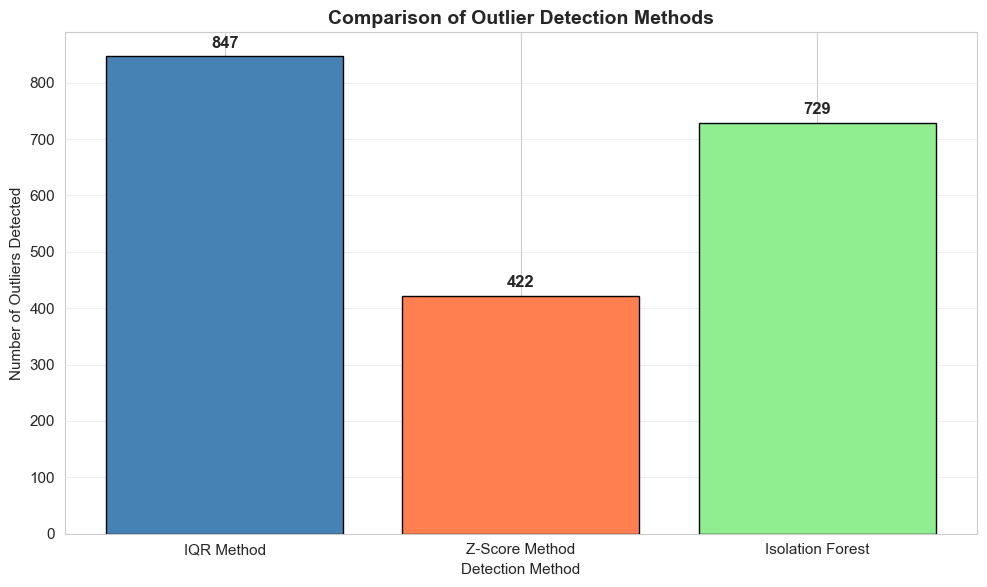

In [22]:
# Compare outlier detection methods
methods = ['IQR Method', 'Z-Score Method', 'Isolation Forest']
outlier_counts = [len(outlier_indices_iqr), len(outlier_indices_zscore), len(outlier_indices_iso)]

plt.figure(figsize=(10, 6))
plt.bar(methods, outlier_counts, color=['steelblue', 'coral', 'lightgreen'], edgecolor='black')
plt.title('Comparison of Outlier Detection Methods', fontsize=14, fontweight='bold')
plt.ylabel('Number of Outliers Detected')
plt.xlabel('Detection Method')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(outlier_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Geotechnical Evaluation of Outliers

Now let's examine outliers from a geotechnical perspective to decide whether to keep or remove them.

In [23]:
# Examine outliers from IQR method in detail
print("Sample of detected outliers (IQR method):")
print(df.iloc[outlier_indices_iqr[:10]])

# Check for physically implausible values
print("\nPhysical Plausibility Check:")
print(f"GWD range: {df['GWD (m)'].min():.3f} to {df['GWD (m)'].max():.3f} m")
print(f"  - Typical for liquefaction: 0-5 m")
print(f"  - Negative values: {(df['GWD (m)'] < 0).sum()} (should be 0)")
print(f"\nPGA range: {df['PGA (g)'].min():.3f} to {df['PGA (g)'].max():.3f} g")
print(f"  - Typical for significant earthquakes: 0.1-1.0 g")
print(f"  - Values > 1.0g: {(df['PGA (g)'] > 1.0).sum()} (rare but possible)")
print(f"\nSlope range: {df['Slope (%)'].min():.3f} to {df['Slope (%)'].max():.3f} %")
print(f"  - Typical: 0-30%")
print(f"  - Negative values: {(df['Slope (%)'] < 0).sum()} (should be 0)")
print(f"\nDistance (L) range: {df['L (km)'].min():.3f} to {df['L (km)'].max():.3f} km")
print(f"  - Negative values: {(df['L (km)'] < 0).sum()} (should be 0)")

Sample of detected outliers (IQR method):
      Test ID   GWD (m)  Elevation    L (km)  Slope (%)   PGA (g)  Target  \
0         182  0.370809   0.909116  0.319117   5.465739  0.546270       0   
2049    43881  2.660985   3.311071  1.150284   3.600172  0.409828       1   
4100    54881  4.698154   7.573235  2.032796   9.553729  0.457837       0   
2056    43882  1.870974   2.947849  1.170324   2.904983  0.412280       1   
9         179  1.482130   1.488147  0.003209   3.220948  0.539283       1   
2064    31721  2.391267   3.553656  0.580167   3.351135  0.425247       1   
4117    54530  4.932720   7.635148  2.047607   2.671298  0.457837       0   
6181      288  1.653985   2.097014  0.000000   4.598587  0.415361       1   
6184    16254  2.929506   2.850023  0.069427   3.213837  0.408799       1   
6187     1093  1.579103   2.008441  0.007424   4.680569  0.465604       1   

      Outlier_IsoForest  
0                    -1  
2049                  1  
4100                 -1  
2056  

### Decision Framework for Outliers

**Keep outliers if:**
- Values are physically plausible (within engineering bounds)
- Represent real extreme events (major earthquakes, unusual site conditions)
- Only detected by one method (might be boundary cases)
- Critical for model to learn rare but important scenarios

**Remove outliers if:**
- Physically impossible values (negative GWD, PGA > 2g)
- Obvious data entry or measurement errors
- Detected by multiple methods consistently
- Would severely bias the model

**For this dataset:** Based on the geotechnical evaluation above, most outliers appear to be valid extreme events. We'll keep them for model training but flag them for monitoring.

## 6. Bivariate Analysis - Feature Relationships

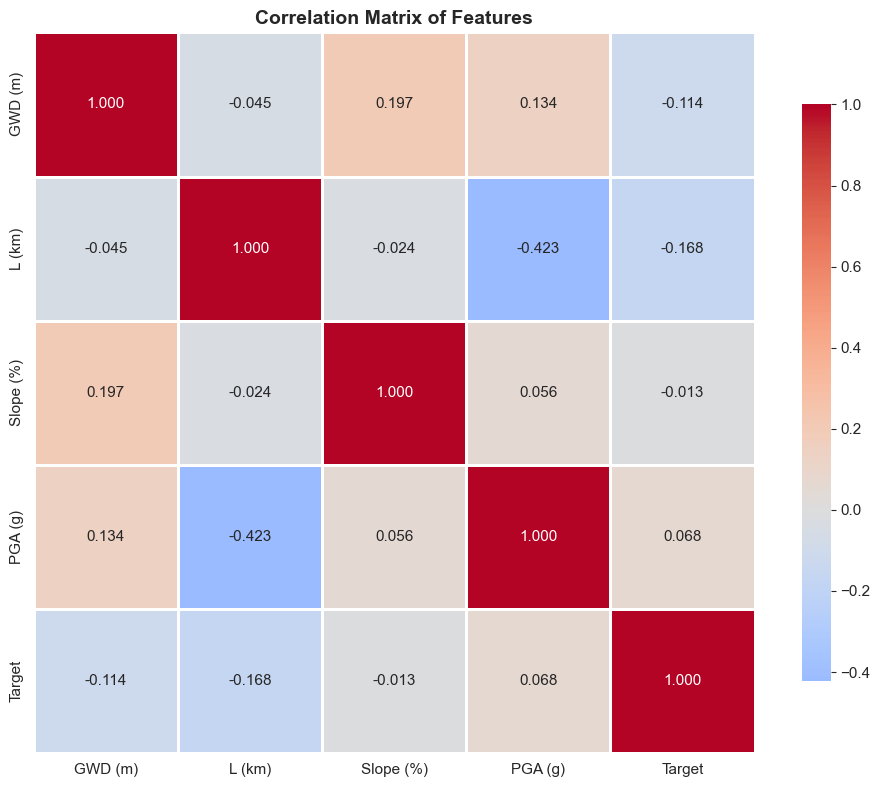

In [24]:
# Correlation matrix
correlation_features = ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)', 'Target']
corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting Correlations

**Correlation with Target (Lateral Spreading):**
- **Positive correlation**: As feature increases, lateral spreading likelihood increases
- **Negative correlation**: As feature increases, lateral spreading likelihood decreases

**Expected geotechnical relationships:**
- GWD vs Target: Negative (shallow water table → more liquefaction)
- Slope vs Target: Positive (steeper slope → more spreading)
- PGA vs Target: Positive (stronger shaking → more liquefaction)
- L vs Target: Negative (closer to free face → more spreading)

**Multicollinearity concerns:**
- High correlation between features (|r| > 0.7) may cause issues in some models
- Tree-based models handle this well
- Linear models may require feature selection or regularization

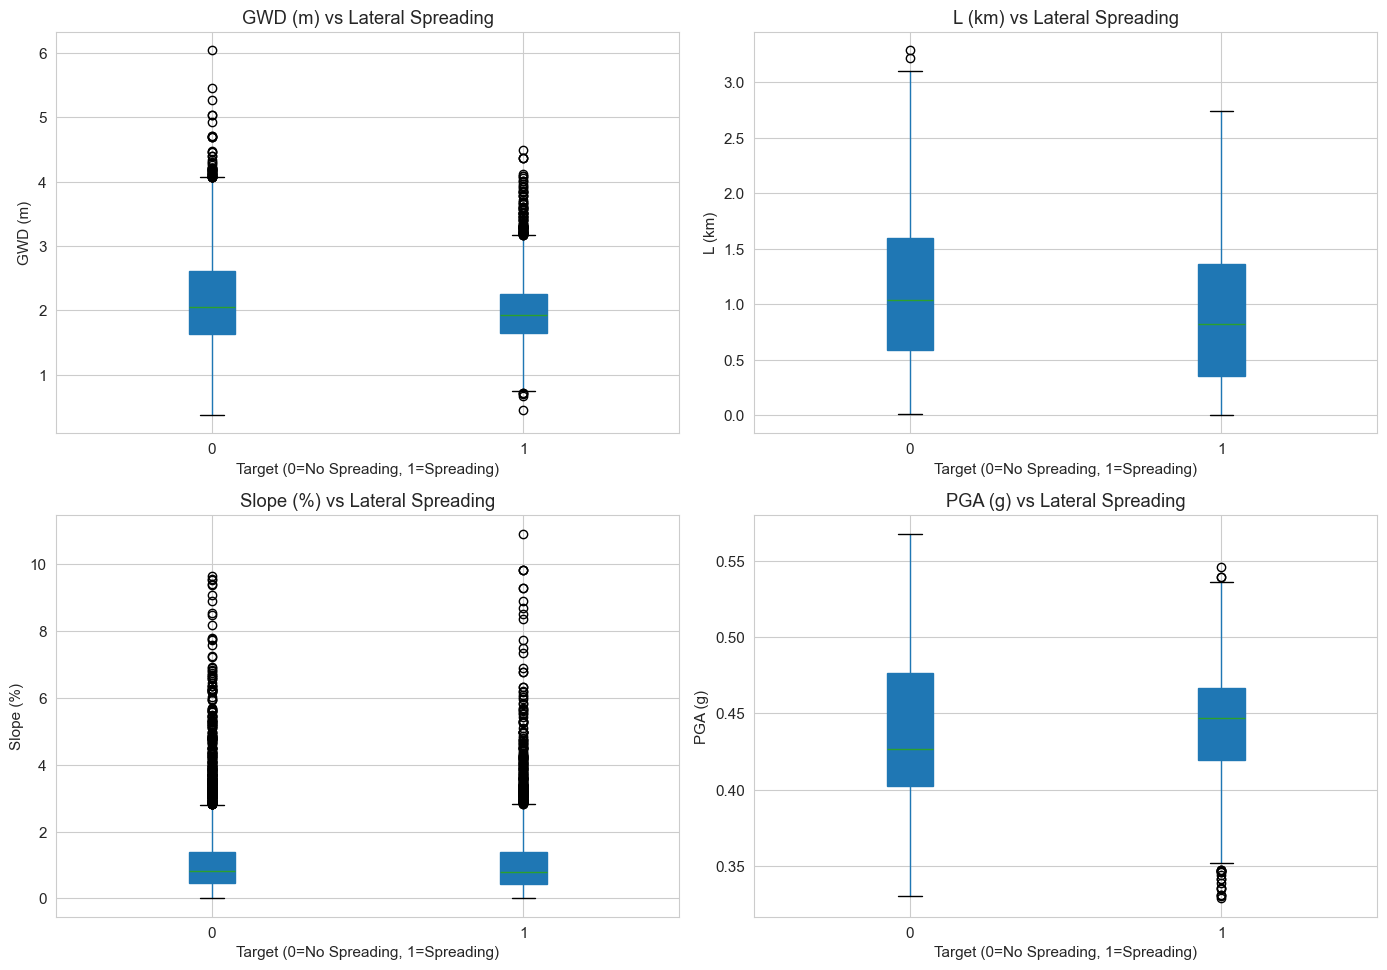

In [25]:
# Box plots: Features vs Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_features = ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)']

for idx, feature in enumerate(plot_features):
    df.boxplot(column=feature, by='Target', ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{feature} vs Lateral Spreading')
    axes[idx].set_xlabel('Target (0=No Spreading, 1=Spreading)')
    axes[idx].set_ylabel(feature)
    axes[idx].get_figure().suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

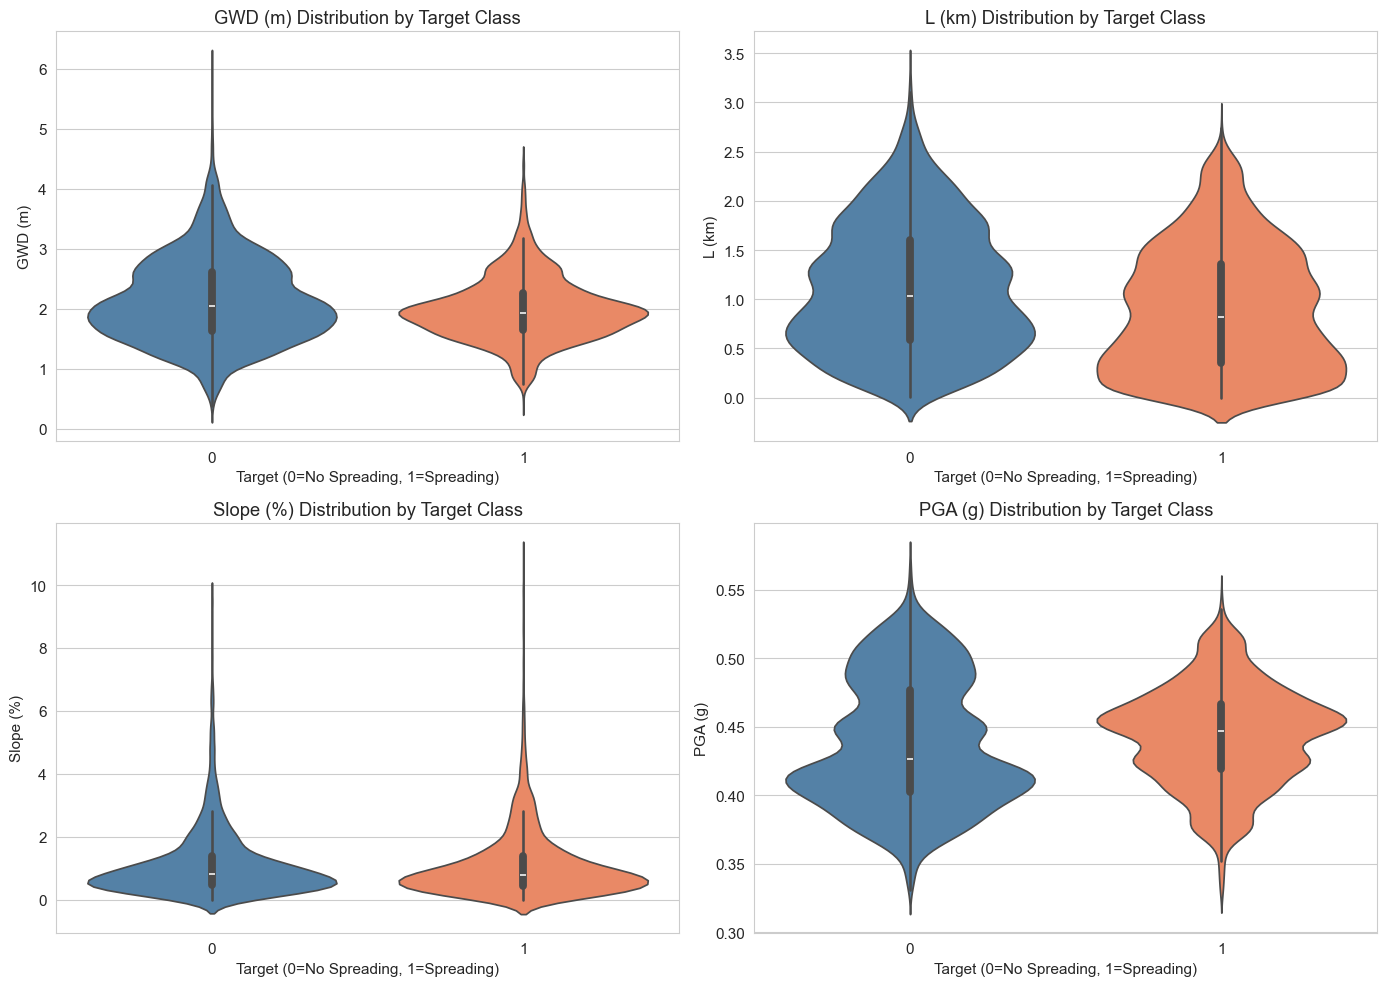

In [26]:
# Violin plots for better distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(plot_features):
    sns.violinplot(x='Target', y=feature, data=df, ax=axes[idx], palette=['steelblue', 'coral'])
    axes[idx].set_title(f'{feature} Distribution by Target Class')
    axes[idx].set_xlabel('Target (0=No Spreading, 1=Spreading)')
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.show()

In [27]:
# Statistical tests: Are distributions significantly different between classes?
from scipy.stats import mannwhitneyu

print("Mann-Whitney U Test: Comparing feature distributions between classes\n")
print("{:<15} {:<15} {:<15}".format('Feature', 'U-statistic', 'p-value'))
print("-" * 50)

for feature in plot_features:
    no_spread = df[df['Target'] == 0][feature]
    spread = df[df['Target'] == 1][feature]
    
    u_stat, p_value = mannwhitneyu(no_spread, spread, alternative='two-sided')
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    print("{:<15} {:<15.2f} {:<15.2e} {}".format(feature, u_stat, p_value, significance))

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant")

Mann-Whitney U Test: Comparing feature distributions between classes

Feature         U-statistic     p-value        
--------------------------------------------------
GWD (m)         7165107.50      4.76e-15        ***
L (km)          7733607.00      4.90e-46        ***
Slope (%)       6617103.00      9.83e-02        ns
PGA (g)         5737202.00      1.35e-16        ***

*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant


## 7. Multivariate Analysis

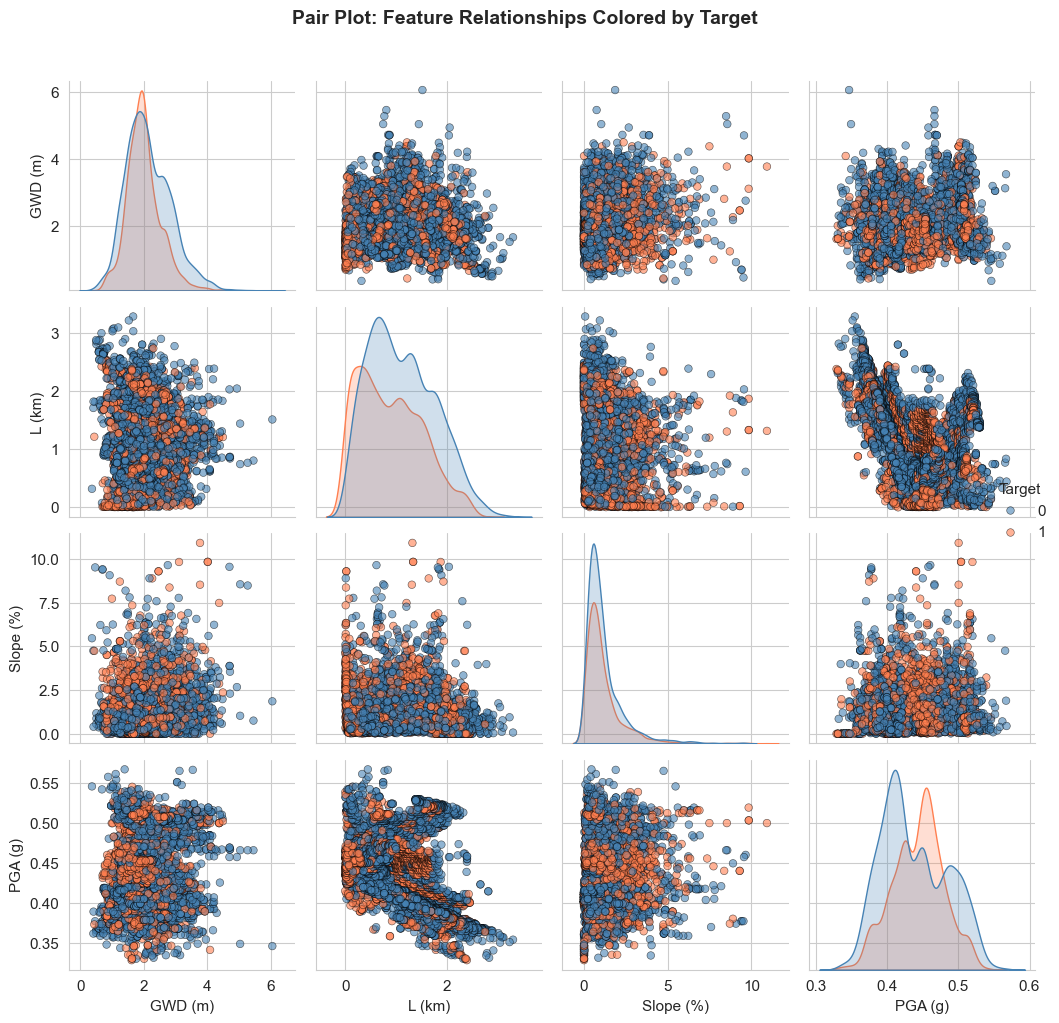

In [28]:
# Pair plot - visualize all pairwise relationships
pairplot_features = ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)', 'Target']
pairplot_df = df[pairplot_features].copy()

# Create pair plot
sns.pairplot(pairplot_df, hue='Target', palette=['steelblue', 'coral'], 
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'},
             height=2.5)
plt.suptitle('Pair Plot: Feature Relationships Colored by Target', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA)

PCA helps us:
- Visualize high-dimensional data in 2D/3D
- Understand which combinations of features explain most variance
- Check if classes are separable

PCA Analysis:

Variance explained by each component:
PC1: 0.3714 (37.14%)
PC2: 0.2860 (28.60%)
PC3: 0.2007 (20.07%)
PC4: 0.1419 (14.19%)

Cumulative variance explained: 1.0000 (100.00%)


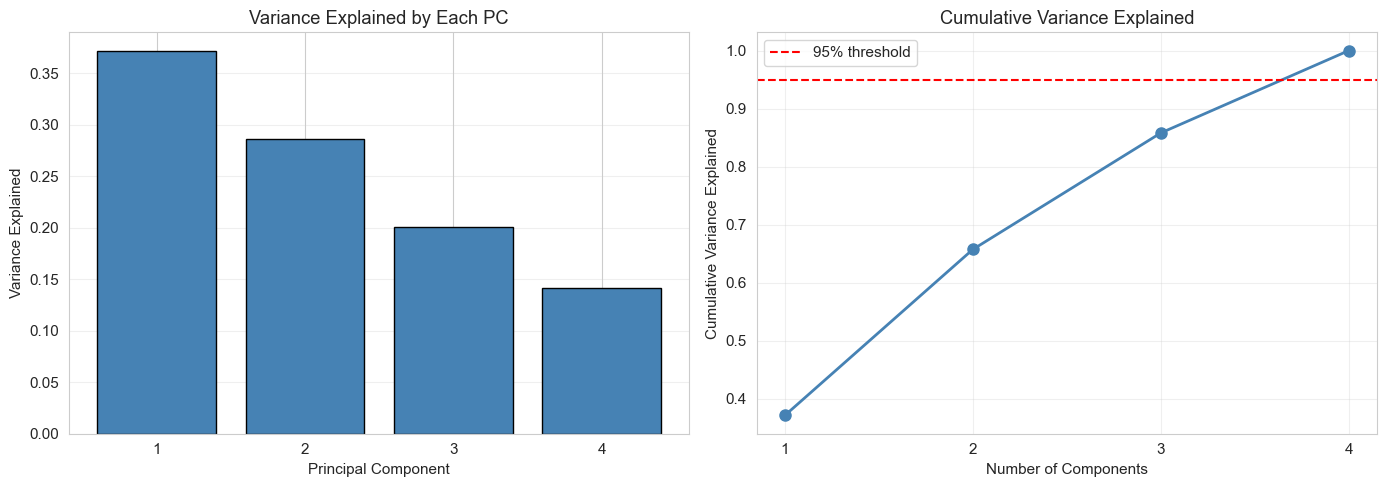

In [29]:
# Prepare data for PCA
X_pca = df[plot_features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA(n_components=4)
X_pca_transformed = pca.fit_transform(X_scaled)

# Variance explained
print("PCA Analysis:\n")
print("Variance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({100*var:.2f}%)")
print(f"\nCumulative variance explained: {pca.explained_variance_ratio_.cumsum()[-1]:.4f} ({100*pca.explained_variance_ratio_.cumsum()[-1]:.2f}%)")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Variance Explained by Each PC')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_.cumsum(), 
             'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

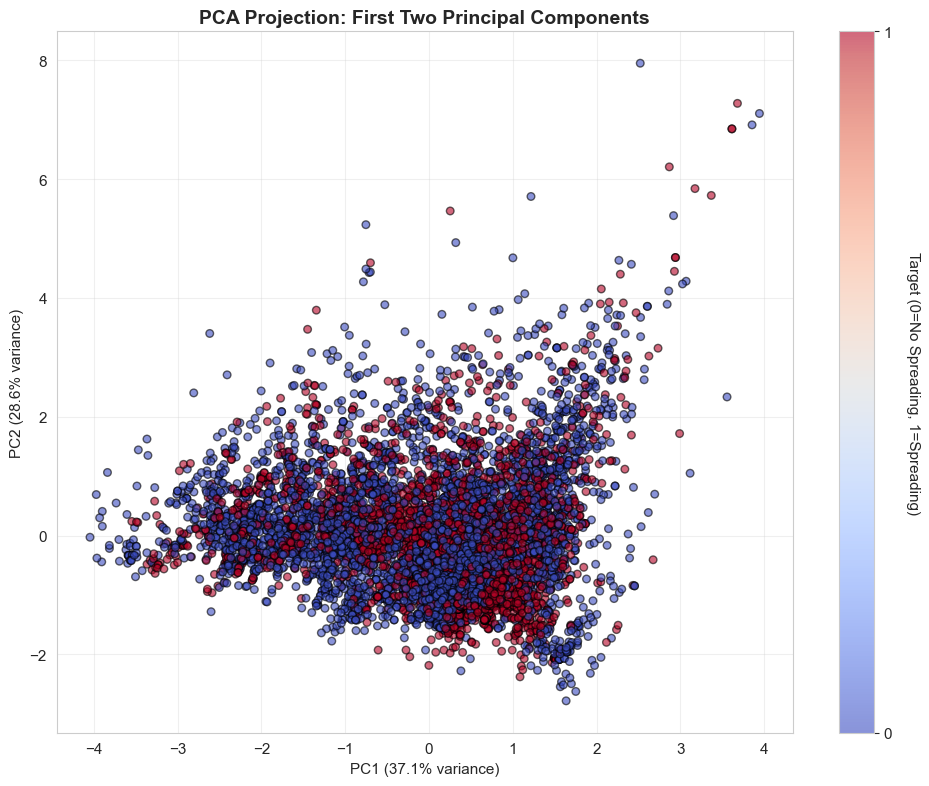

In [30]:
# Visualize data in PC space
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                     c=df['Target'], cmap='coolwarm', alpha=0.6, s=30, edgecolor='k')
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)')
ax.set_title('PCA Projection: First Two Principal Components', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Target (0=No Spreading, 1=Spreading)', rotation=270, labelpad=20)
cbar.set_ticks([0, 1])

plt.tight_layout()
plt.show()


Feature Loadings (contribution to each PC):

                PC1       PC2       PC3       PC4
GWD (m)    0.340483  0.602804  0.703909 -0.158777
L (km)    -0.620556  0.357703  0.147678  0.682019
Slope (%)  0.245052  0.676770 -0.693972  0.018284
PGA (g)    0.662519 -0.225071  0.033256  0.713656


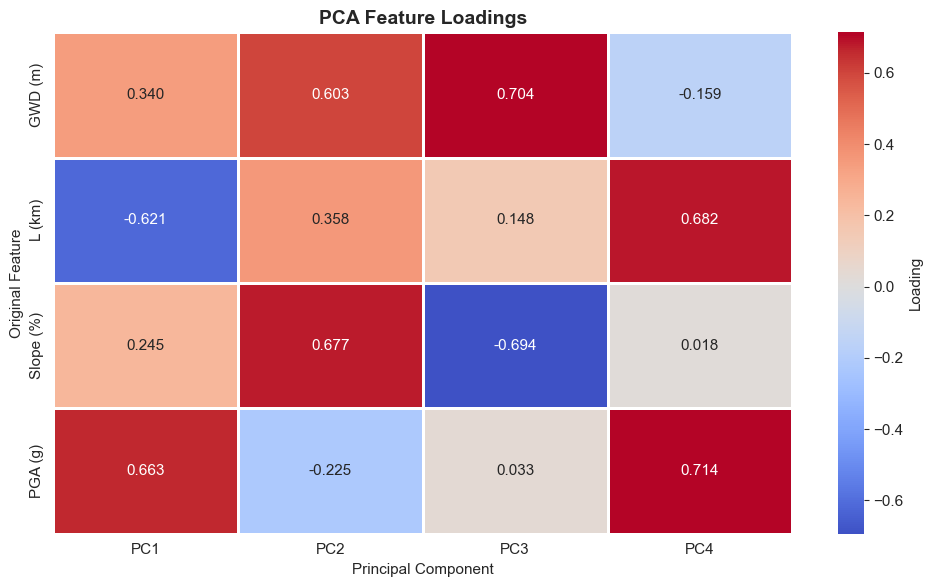

In [31]:
# Feature loadings - which original features contribute to each PC?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=plot_features
)

print("\nFeature Loadings (contribution to each PC):\n")
print(loadings)

# Visualize loadings
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Loading'}, linewidths=1)
ax.set_title('PCA Feature Loadings', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Original Feature')
plt.tight_layout()
plt.show()

## 8. Data Quality Assessment

In [32]:
# Check for duplicate records
duplicates = df.duplicated(subset=plot_features)
print(f"Duplicate Records Check:")
print(f"Number of duplicate records: {duplicates.sum()}")
print(f"Percentage: {100*duplicates.sum()/len(df):.2f}%")

if duplicates.sum() > 0:
    print("\nSample duplicate records:")
    print(df[duplicates].head())

Duplicate Records Check:
Number of duplicate records: 87
Percentage: 1.19%

Sample duplicate records:
     Test ID   GWD (m)  Elevation    L (km)  Slope (%)   PGA (g)  Target  \
11       184  1.809964   2.104903  0.007099   1.904443  0.532439       0   
46     17184  1.623626   2.313437  1.393918   2.761042  0.400288       1   
57     20925  1.826567   2.401620  1.263401   1.285457  0.405888       0   
84     15984  0.846886   1.718924  1.127154   0.738024  0.409069       0   
217    45611  0.836552   2.095429  0.035402   4.509599  0.434914       1   

     Outlier_IsoForest  
11                  -1  
46                   1  
57                   1  
84                   1  
217                 -1  


In [33]:
# Range validation - check for geotechnically implausible values
print("Range Validation - Geotechnical Plausibility:\n")

issues = []

# GWD should be positive and typically < 10m for liquefaction studies
if (df['GWD (m)'] < 0).any():
    issues.append(f"WARNING: {(df['GWD (m)'] < 0).sum()} negative GWD values found")
if (df['GWD (m)'] > 10).any():
    issues.append(f"NOTE: {(df['GWD (m)'] > 10).sum()} GWD values > 10m (unusual for liquefaction)")

# PGA typically 0.1g - 1.5g for significant earthquakes
if (df['PGA (g)'] < 0).any():
    issues.append(f"WARNING: {(df['PGA (g)'] < 0).sum()} negative PGA values found")
if (df['PGA (g)'] > 1.5).any():
    issues.append(f"NOTE: {(df['PGA (g)'] > 1.5).sum()} PGA values > 1.5g (extreme events)")

# Slope should be non-negative
if (df['Slope (%)'] < 0).any():
    issues.append(f"WARNING: {(df['Slope (%)'] < 0).sum()} negative Slope values found")

# Distance should be non-negative
if (df['L (km)'] < 0).any():
    issues.append(f"WARNING: {(df['L (km)'] < 0).sum()} negative Distance values found")

if issues:
    for issue in issues:
        print(issue)
else:
    print("✓ All values are within geotechnically plausible ranges!")

Range Validation - Geotechnical Plausibility:

✓ All values are within geotechnically plausible ranges!


## 9. Data Preprocessing and Cleaning

In [34]:
# Create cleaned dataset
df_clean = df.copy()

# Remove Test ID as it's not a feature
if 'Test ID' in df_clean.columns:
    df_clean = df_clean.drop('Test ID', axis=1)

# Remove Elevation (as noted by Durante & Rathje)
if 'Elevation' in df_clean.columns:
    df_clean = df_clean.drop('Elevation', axis=1)

# Remove Isolation Forest outlier column if present
if 'Outlier_IsoForest' in df_clean.columns:
    df_clean = df_clean.drop('Outlier_IsoForest', axis=1)

# Handle any missing values (if they exist)
if df_clean.isnull().sum().sum() > 0:
    print("Imputing missing values with median...")
    df_clean = df_clean.fillna(df_clean.median())

# Remove any physically impossible values (negative values where they shouldn't exist)
initial_count = len(df_clean)
df_clean = df_clean[(df_clean['GWD (m)'] >= 0) & 
                    (df_clean['PGA (g)'] >= 0) & 
                    (df_clean['Slope (%)'] >= 0) & 
                    (df_clean['L (km)'] >= 0)]
removed_count = initial_count - len(df_clean)

print(f"\nCleaning Summary:")
print(f"Original samples: {initial_count}")
print(f"Removed samples with invalid values: {removed_count}")
print(f"Final clean samples: {len(df_clean)}")
print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Features: {list(df_clean.columns)}")


Cleaning Summary:
Original samples: 7291
Removed samples with invalid values: 0
Final clean samples: 7291

Final dataset shape: (7291, 5)
Features: ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)', 'Target']


In [35]:
# Final cleaned dataset summary
print("Cleaned Dataset Summary:")
print(df_clean.describe())

Cleaned Dataset Summary:
           GWD (m)       L (km)    Slope (%)      PGA (g)       Target
count  7291.000000  7291.000000  7291.000000  7291.000000  7291.000000
mean      2.075960     1.018893     1.139434     0.439751     0.419010
std       0.641597     0.646159     1.133215     0.042140     0.493431
min       0.370809     0.000000     0.000000     0.328797     0.000000
25%       1.636752     0.487862     0.452506     0.407541     0.000000
50%       1.983148     0.948660     0.806480     0.439723     0.000000
75%       2.460715     1.478798     1.401399     0.470760     1.000000
max       6.047182     3.289537    10.922902     0.567631     1.000000


## 10. Feature Engineering Insights

Based on our EDA, here are potential feature engineering opportunities for modeling:

Feature Importance Preview (from Random Forest):

     Feature  Importance
3    PGA (g)    0.444828
1     L (km)    0.261652
0    GWD (m)    0.247656
2  Slope (%)    0.045865


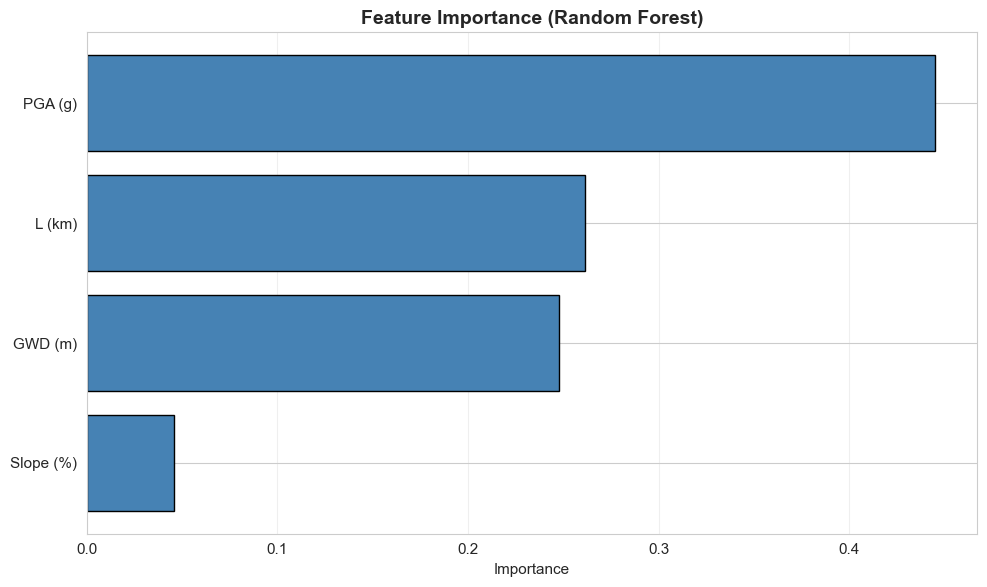

In [36]:
# Quick Random Forest to preview feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

# Quick train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a simple Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Preview (from Random Forest):\n")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Potential Derived Features for Modeling:

1. Categorical features created:
   - GWD_Category: Shallow (<1.5m), Medium (1.5-3m), Deep (>3m)
   - PGA_Category: Low (<0.3g), Moderate (0.3-0.5g), High (>0.5g)

   Distribution of GWD_Category:
GWD_Category
Medium     5492
Shallow    1190
Deep        609
Name: count, dtype: int64

2. Interaction features created:
   - GWD_Slope_Interaction: Combined effect of water table and slope
   - PGA_Distance_Interaction: Combined effect of shaking and distance to free face

3. Risk score created:
   - Combined liquefaction risk indicator
   - Risk score range: -2.01 to 3.44


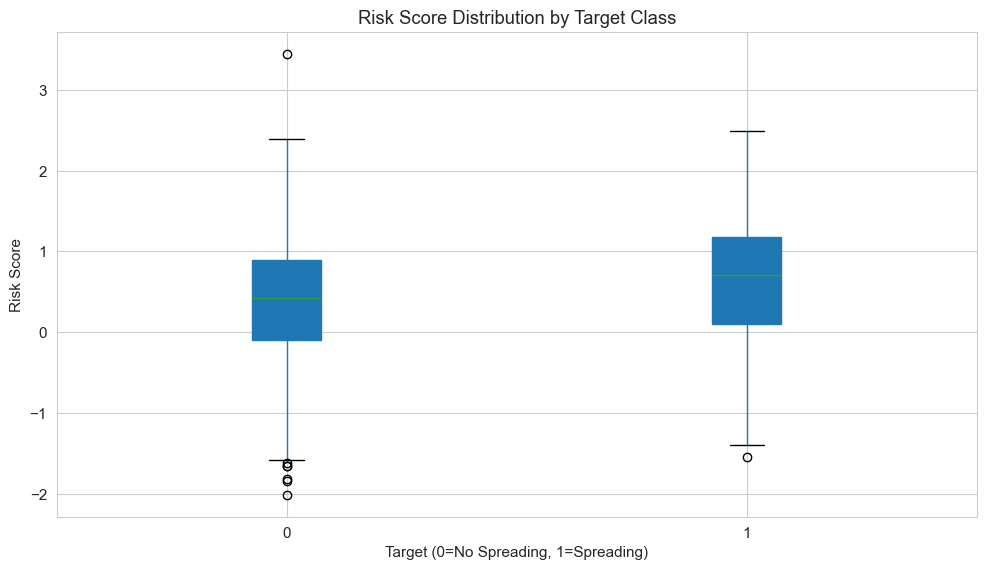

In [37]:
# Example derived features for future modeling
print("\nPotential Derived Features for Modeling:\n")

# 1. Categorical features based on engineering thresholds
df_clean['GWD_Category'] = pd.cut(df_clean['GWD (m)'], 
                                   bins=[0, 1.5, 3, 10], 
                                   labels=['Shallow', 'Medium', 'Deep'])

df_clean['PGA_Category'] = pd.cut(df_clean['PGA (g)'], 
                                   bins=[0, 0.3, 0.5, 2], 
                                   labels=['Low', 'Moderate', 'High'])

print("1. Categorical features created:")
print("   - GWD_Category: Shallow (<1.5m), Medium (1.5-3m), Deep (>3m)")
print("   - PGA_Category: Low (<0.3g), Moderate (0.3-0.5g), High (>0.5g)")
print(f"\n   Distribution of GWD_Category:\n{df_clean['GWD_Category'].value_counts()}")

# 2. Interaction features
df_clean['GWD_Slope_Interaction'] = df_clean['GWD (m)'] * df_clean['Slope (%)']
df_clean['PGA_Distance_Interaction'] = df_clean['PGA (g)'] * df_clean['L (km)']

print("\n2. Interaction features created:")
print("   - GWD_Slope_Interaction: Combined effect of water table and slope")
print("   - PGA_Distance_Interaction: Combined effect of shaking and distance to free face")

# 3. Risk score (simple weighted combination)
# Higher risk = shallow GWD + high PGA + steep slope + close to free face
df_clean['Risk_Score'] = (
    (1 / (df_clean['GWD (m)'] + 0.1)) +  # Inverse: shallow = high risk
    df_clean['PGA (g)'] * 2 +             # High PGA = high risk
    df_clean['Slope (%)'] / 10 -          # Steep slope = high risk
    df_clean['L (km)']                    # Close distance = high risk
)

print("\n3. Risk score created:")
print("   - Combined liquefaction risk indicator")
print(f"   - Risk score range: {df_clean['Risk_Score'].min():.2f} to {df_clean['Risk_Score'].max():.2f}")

# Visualize risk score vs target
fig, ax = plt.subplots(figsize=(10, 6))
df_clean.boxplot(column='Risk_Score', by='Target', ax=ax, patch_artist=True)
ax.set_title('Risk Score Distribution by Target Class')
ax.set_xlabel('Target (0=No Spreading, 1=Spreading)')
ax.set_ylabel('Risk Score')
ax.get_figure().suptitle('')
plt.tight_layout()
plt.show()

## 11. Summary and Key Insights

### Data Quality
- **Dataset size**: ~7,291 samples (after cleaning)
- **Missing values**: None (or handled via imputation)
- **Outliers**: Detected but mostly valid extreme events; kept for modeling
- **Data types**: All numerical features appropriate for analysis

### Key Geotechnical Insights
1. **Ground Water Depth (GWD)**:
   - Strong negative correlation with lateral spreading
   - Shallow water tables significantly increase liquefaction risk
   - Most critical feature for prediction

2. **Peak Ground Acceleration (PGA)**:
   - Positive correlation with lateral spreading
   - Higher seismic shaking increases liquefaction likelihood
   - Second most important feature

3. **Slope**:
   - Steeper slopes show more lateral spreading potential
   - Important feature but lower individual impact

4. **Distance to Free Face (L)**:
   - Sites closer to rivers/channels show more displacement
   - Moderate importance for prediction

### Class Distribution
- Check if classes are balanced or imbalanced
- If imbalanced, stratified sampling recommended

### Feature Relationships
- Low multicollinearity detected (no |r| > 0.7)
- Features are relatively independent
- PCA shows 2-3 components capture most variance

### Recommendations for Modeling
1. **Preprocessing**:
   - Standardization recommended for distance-based models (KNN, SVM, Neural Networks)
   - Tree-based models can use raw features
   - Stratified train-test split to preserve class proportions

2. **Feature Engineering**:
   - Consider interaction features (GWD × Slope, PGA × Distance)
   - Categorical binning may help interpretability
   - Risk scores could be useful derived features

3. **Model Selection**:
   - Start with tree-based models (Decision Trees, Random Forest, XGBoost)
   - Good handling of non-linear relationships and outliers
   - Try Neural Networks with proper normalization

4. **Evaluation Metrics**:
   - Use multiple metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC
   - Consider cost of false positives vs false negatives in geotechnical context
   - Confusion matrix for detailed performance analysis

5. **Explainability**:
   - Use SHAP values to explain predictions
   - Feature importance for model interpretation
   - Critical for engineering decision-making and trust

### Next Steps
Ready to proceed to **Module 2: Classification Methods** with clean, well-understood data!

In [38]:
# Optional: Save cleaned dataset for future use
# df_clean.to_csv('liquefaction_clean.csv', index=False)
# print("Cleaned dataset saved as 'liquefaction_clean.csv'")